### TTS Content Moderation with Toxicity Filtering

Short Description
This implementation demonstrates a content moderation system for text-to-speech applications that detects and blocks toxic content before synthesis. It trains an LSTM-based toxicity classifier on simulated text data, integrates with a TTS pipeline, and prevents harmful content from being vocalized while providing classification performance metrics.

Key Libraries Used

    transformers: TTS pipeline integration

    torch/torch.nn: Neural network implementation

    sklearn: Classification performance metrics

Code Logic and Flow

High-Level Overview
The workflow generates a balanced dataset of safe and toxic text samples, trains a lightweight LSTM classifier to detect harmful content, then integrates this filter with a TTS system. During operation, toxic inputs are blocked from synthesis while safe texts are passed to the TTS engine, creating an ethical content moderation barrier.

Visual FlowChart:

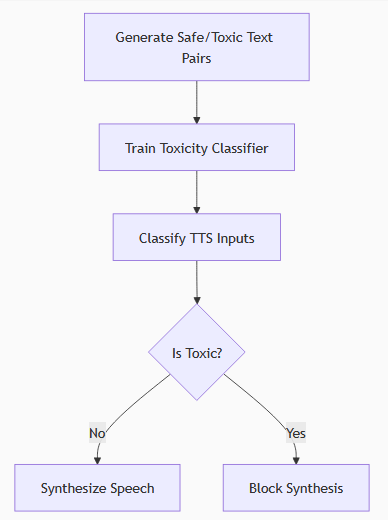

Step-by-Step Code Breakdown

1. Simulated Text Dataset

    Creates balanced dataset of 200 samples

    Defines four text templates (2 safe, 2 toxic)

    Labels: 0 (safe) vs 1 (toxic)

    Replicates templates for dataset scaling

2. Toxicity Classifier Architecture

    Embedding Layer: Converts words to vectors

    LSTM Layer: Captures sequential context

    Classification Head:

        Linear layers with ReLU activation

        Dropout for regularization

    Handles variable-length inputs via padding

3. Training Pipeline

    Builds vocabulary from unique words

    Converts text to padded indices

    Uses Cross-Entropy loss and Adam optimizer

    5-epoch training with batch processing

4. TTS Integration & Moderation

    Initializes suno/bark-small TTS pipeline

    Moderation Workflow:

        Classifies each input text

        Blocks toxic content with warning

        Synthesizes safe texts to speech

    Generates classification report:

        Precision/recall for safe/toxic classes

Connecting to the Lecture

    Ethical Safeguards: Prevents vocalization of harmful content

    Real-Time Filtering: Lightweight model enables low-latency moderation

    Context Awareness: LSTM captures linguistic nuances in toxicity

    Resource Efficiency: Designed for 6GB GPU constraints

    Responsible AI: Demonstrates content governance for TTS systems

    Simulated Testing: Safe experimentation with sensitive content

    Performance Metrics: Quantifies moderation system effectiveness

    Integration Pattern: Shows extensible architecture for production TTS

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import pipeline
import numpy as np
from sklearn.metrics import classification_report

# --- Simulated Text Dataset for TTS ---
class TextDataset(Dataset):
    """Simulated dataset with text samples for TTS, labeled as safe or toxic"""
    def __init__(self, num_samples=200):
        self.num_samples = num_samples
        self.texts = [
            "Hello, how can I assist you today?",  # Safe
            "You are an idiot, get lost!",         # Toxic
            "I hope you have a great day!",        # Safe
            "This is a scam, give me your money!"  # Toxic
        ] * (num_samples // 4)
        self.labels = [0, 1, 0, 1] * (num_samples // 4)  # 0: safe, 1: toxic
        self.text_to_idx = {t: i for i, t in enumerate(self.texts)}

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        return text, label

# --- Toxicity Classifier ---
class ToxicityClassifier(nn.Module):
    """Lightweight text classifier for detecting toxic content"""
    def __init__(self, vocab_size=100, embed_dim=64, hidden_dim=128, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, text_indices):
        x = self.embedding(text_indices)  # [batch, seq_len, embed_dim]
        _, (hn, _) = self.lstm(x)  # hn: [1, batch, hidden_dim]
        x = hn.squeeze(0)  # [batch, hidden_dim]
        x = self.fc(x)  # [batch, num_classes]
        return x

# --- TTS with Content Moderation ---
def tts_with_moderation():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Dataset and dataloader
    dataset = TextDataset(num_samples=200)
    dataloader = DataLoader(dataset, batch_size=8, shuffle=True)  # Moderate batch size for 6 GB VRAM

    # Simple vocabulary for text encoding
    vocab = set(" ".join(dataset.texts).split())
    vocab = {word: idx + 1 for idx, word in enumerate(vocab)}  # 0 for padding
    vocab["<pad>"] = 0

    # Model, loss, optimizer
    model = ToxicityClassifier(vocab_size=len(vocab) + 1, embed_dim=64, hidden_dim=128, num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    num_epochs = 5

    # Training loop
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for texts, labels in dataloader:
            # Encode texts
            text_indices = [[vocab.get(word, 0) for word in text.split()] for text in texts]
            max_len = max(len(indices) for indices in text_indices)
            text_indices = [indices + [0] * (max_len - len(indices)) for indices in text_indices]
            text_indices = torch.tensor(text_indices, dtype=torch.long).to(device)
            labels = labels.to(device)
            logits = model(text_indices)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(dataloader):.4f}")

    # Evaluation and TTS simulation
    model.eval()
    all_preds = []
    all_labels = []
    tts_pipeline = pipeline("text-to-speech", model="suno/bark-small", device=device if device.type == "cuda" else -1)
    with torch.no_grad():
        for texts, labels in dataloader:
            text_indices = [[vocab.get(word, 0) for word in text.split()] for text in texts]
            max_len = max(len(indices) for indices in text_indices)
            text_indices = [indices + [0] * (max_len - len(indices)) for indices in text_indices]
            text_indices = torch.tensor(text_indices, dtype=torch.long).to(device)
            logits = model(text_indices)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            # Simulate TTS with moderation
            for text, pred in zip(texts, preds):
                if pred == 0:  # Safe
                    print(f"Safe text: '{text}' -> Synthesizing audio...")
                    # tts_pipeline(text)  # Uncomment to synthesize (disabled for speed)
                else:
                    print(f"Toxic text detected: '{text}' -> Blocked from TTS.")
    
    print("\nToxicity Classifier Performance:")
    print(classification_report(all_labels, all_preds, target_names=["Safe", "Toxic"]))
    return model, dataset

# --- Main Execution ---
if __name__ == "__main__":
    model, dataset = tts_with_moderation()
    print("TTS content moderation completed.")

# Explanation:

#     Dataset: Simulates a text dataset for TTS with safe and toxic samples, labeled accordingly.
#     Model: A lightweight LSTM-based classifier detects toxic content in text before TTS synthesis, suitable for 6 GB VRAM.
#     Process: Trains the classifier to identify toxic text and blocks it from being synthesized by a TTS pipeline (using suno/bark-small for demonstration, commented out to save resources).
#     Educational Value: Demonstrates output moderation to prevent harmful content in TTS, addressing a key ethical concern in SpeechLMs.
#     Hardware Fit: Small batch size (8) and lightweight model ensure compatibility with 6 GB VRAM. The TTS pipeline is optional and can run on CPU if needed.    

Using device: cpu
Epoch 1/5 | Loss: 0.4404
Epoch 2/5 | Loss: 0.0133
Epoch 3/5 | Loss: 0.0004
Epoch 4/5 | Loss: 0.0002
Epoch 5/5 | Loss: 0.0001


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

speaker_embeddings_path.json: 0.00B [00:00, ?B/s]

Device set to use cpu


Toxic text detected: 'You are an idiot, get lost!' -> Blocked from TTS.
Toxic text detected: 'You are an idiot, get lost!' -> Blocked from TTS.
Toxic text detected: 'This is a scam, give me your money!' -> Blocked from TTS.
Toxic text detected: 'You are an idiot, get lost!' -> Blocked from TTS.
Toxic text detected: 'This is a scam, give me your money!' -> Blocked from TTS.
Safe text: 'I hope you have a great day!' -> Synthesizing audio...
Safe text: 'I hope you have a great day!' -> Synthesizing audio...
Toxic text detected: 'You are an idiot, get lost!' -> Blocked from TTS.
Safe text: 'I hope you have a great day!' -> Synthesizing audio...
Safe text: 'Hello, how can I assist you today?' -> Synthesizing audio...
Toxic text detected: 'This is a scam, give me your money!' -> Blocked from TTS.
Safe text: 'I hope you have a great day!' -> Synthesizing audio...
Toxic text detected: 'This is a scam, give me your money!' -> Blocked from TTS.
Toxic text detected: 'You are an idiot, get lost!' 